<a href="https://colab.research.google.com/github/RenataH02/Computer_Vision_Project/blob/main/stage%201" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Project Stage 1: Classification Baselines

**Self contained, reproducible report.** Every number, table and figure below is
computed when you *Run All* . The notebook carries
its own implementation of both baselines, so the only input it needs is the
cached encoder features (and it can extract those itself on a GPU runtime).

Runs on **Google Colab** or locally; the only libraries required for the analysis
are NumPy, pandas, scikit-learn and Matplotlib.

## Goal

Stage 1 establishes a reliable, reproducible classification pipeline on top of
**frozen** pretrained encoders. No flow matching component is used here. We
implement the **required linear probe** plus **one** prototype based branch, on
**two** of the three offered datasets.

## Our chosen bundle, and why

| Choice | Decision | Rationale |
|---|---|---|
| **Datasets** | **DTD** + **Oxford Flowers-102** | DTD is small, fast and *out of domain* for an ImageNet-trained ResNet-18 (textures, not objects), which makes the encoder comparison informative. Flowers-102 is a clean fine-grained *object* dataset giving interpretable results and well formed clusters. Together they cover two contrasting domains; we avoided FGVC-Aircraft, which is markedly slower and harder without adding a new axis of comparison. |
| **Prototype branch** | **Option A : image derived prototypes** | It reuses the *exact same cached features and encoders* as the linear probe (no extra model), yields a full 5/10/full curve directly comparable to the probe, and its prototypes drop straight into the feature visualizations. Option B (zero shot CLIP) would have required a separate model and produced only a single point per dataset. |
| **DINOv2 dataset** | **Flowers-102** (ResNet-18 on both) | DINOv2 ViT-S/14 shows its largest and clearest gain over an ImageNet ResNet-18 on fine grained data, making the encoder comparison maximally informative. |

## Pipeline architecture

Because the encoders are frozen, features are extracted **once** and cached. That
cleanly splits an expensive GPU stage from a cheap CPU stage:

```
  GPU stage (once)                     CPU stage (this report)
  ----------------                     -----------------------
  download DTD + Flowers-102           balanced K shot subset sampling (seeded)
  run frozen ResNet-18 / DINOv2   -->  linear probe (NumPy AdamW + cross-entropy)
  cache features/*.npz                 image derived prototypes
                                       metrics, confusion matrices, plots, t-SNE
```

The analysis needs **no PyTorch** — the linear probe is implemented in pure NumPy.

---
# Part 1 — Obtaining the cached features

The notebook needs a `features/` folder containing, for each dataset/encoder pair,
one `.npz` per split (`features`, `labels` arrays) plus a `<dataset>_classes.json`.

Set `FEATURE_SOURCE` below:

| Value | Behaviour |
|---|---|
| `'auto'` | Use `features/` if it is already there; otherwise fall back to `'upload'`. |
| `'upload'` | Prompt for a `features.zip` upload (Colab) and unzip it. |
| `'drive'` | Mount Google Drive and copy `features/` from `DRIVE_FEATURES_PATH`. |
| `'extract'` | Run the frozen encoders here to build the cache from scratch (**needs a GPU runtime**; downloads both datasets, ~10–15 min). |

In [ ]:
FEATURE_SOURCE = 'auto'
DRIVE_FEATURES_PATH = '/content/drive/MyDrive/cvlab/features'

import json
import shutil
import sys
from pathlib import Path

import numpy as np

IN_COLAB = 'google.colab' in sys.modules

# Run from the project root if the notebook sits inside it.
ROOT = Path.cwd()
FEATURES_DIR = ROOT / 'features'

REQUIRED = [('dtd', 'resnet18'), ('flowers102', 'resnet18'), ('flowers102', 'dinov2')]
SPLITS = ('train', 'val', 'test')


def caches_present(base=None):
    base = base or FEATURES_DIR
    return all((base / f'{ds}_{enc}_{sp}.npz').exists()
               for ds, enc in REQUIRED for sp in SPLITS)


def flatten_features_dir(base):
    """Fix the common 'features/features/...' nesting produced by unzipping."""
    nested = base / 'features'
    if nested.is_dir():
        for item in nested.iterdir():
            shutil.move(str(item), str(base / item.name))
        nested.rmdir()
        print('flattened nested features/features/ folder')


FEATURES_DIR.mkdir(exist_ok=True)
flatten_features_dir(FEATURES_DIR)

source = FEATURE_SOURCE
if source == 'auto':
    source = 'none' if caches_present() else 'upload'

if source == 'upload':
    from google.colab import files
    print('Select your features.zip ...')
    uploaded = files.upload()
    for name in uploaded:
        shutil.unpack_archive(name, str(FEATURES_DIR))
    flatten_features_dir(FEATURES_DIR)
elif source == 'drive':
    from google.colab import drive
    drive.mount('/content/drive')
    for item in Path(DRIVE_FEATURES_PATH).iterdir():
        shutil.copy(str(item), str(FEATURES_DIR / item.name))
    flatten_features_dir(FEATURES_DIR)

print('\nfeatures dir:', FEATURES_DIR.resolve())
print('all caches present:', caches_present())
for f in sorted(FEATURES_DIR.glob('*')):
    print(f'  {f.name:34s} {f.stat().st_size / 1e6:7.2f} MB')

Select your features.zip ...



features dir: /content/features
all caches present: False


### Optional: extract the features here (GPU runtime)

Only runs when `FEATURE_SOURCE = 'extract'` or the cache is still missing. It
downloads DTD (official **partition 1**) and Oxford Flowers-102, then runs the
**frozen** encoders over the official train/val/test splits:

- **ResNet-18** (ImageNet-1K, torchvision) → 512-d representation taken *before*
  the final FC layer, using the checkpoint's own preprocessing.
- **DINOv2 ViT-S/14** (torch.hub) → 384-d final CLS token, 224 px input (a
  multiple of the /14 patch size).

In [ ]:
if FEATURE_SOURCE == 'extract' or not caches_present():
    import torch
    from torch.utils.data import DataLoader
    from torchvision import transforms
    from torchvision.datasets import DTD, Flowers102
    from torchvision.models import ResNet18_Weights, resnet18

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print('device:', device, '(a GPU runtime is strongly recommended)')
    IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
    DATA_ROOT = ROOT / 'data'

    def build_encoder(name):
        if name == 'resnet18':
            model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            model.fc = torch.nn.Identity()               # -> 512-d pre-FC feature
            tf = ResNet18_Weights.IMAGENET1K_V1.transforms()
        else:
            model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
            tf = transforms.Compose([
                transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        model.eval().to(device)
        for p in model.parameters():
            p.requires_grad_(False)                      # keep the encoder frozen
        return model, tf

    def build_dataset(ds, split, tf):
        if ds == 'dtd':
            d = DTD(root=str(DATA_ROOT), split=split, partition=1, transform=tf, download=True)
            return d, list(getattr(d, 'classes', []))
        d = Flowers102(root=str(DATA_ROOT), split=split, transform=tf, download=True)
        return d, [f'class_{i}' for i in range(102)]     # torchvision ships no names

    @torch.no_grad()
    def run_encoder(model, loader):
        feats, labels = [], []
        for images, targets in loader:
            out = model(images.to(device, non_blocking=True))
            feats.append(out.flatten(1).cpu().numpy().astype(np.float32))
            labels.append(np.asarray(targets, dtype=np.int64))
        return np.concatenate(feats), np.concatenate(labels)

    for ds, enc in REQUIRED:
        model, tf = build_encoder(enc)
        for split in SPLITS:
            dset, class_names = build_dataset(ds, split, tf)
            loader = DataLoader(dset, batch_size=128, shuffle=False, num_workers=2)
            X, y = run_encoder(model, loader)
            np.savez_compressed(FEATURES_DIR / f'{ds}_{enc}_{split}.npz', features=X, labels=y)
            print(f'  {ds}/{enc}/{split}: {X.shape}')
        if class_names:
            (FEATURES_DIR / f'{ds}_classes.json').write_text(json.dumps(class_names), encoding='utf-8')
    print('extraction complete')
else:
    print('Features already cached — skipping extraction.')

device: cuda (a GPU runtime is strongly recommended)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]
100%|██████████| 625M/625M [00:24<00:00, 25.4MB/s]


  dtd/resnet18/train: (1880, 512)
  dtd/resnet18/val: (1880, 512)
  dtd/resnet18/test: (1880, 512)


100%|██████████| 345M/345M [00:21<00:00, 15.9MB/s]
100%|██████████| 502/502 [00:00<00:00, 353kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 10.0MB/s]


  flowers102/resnet18/train: (1020, 512)
  flowers102/resnet18/val: (1020, 512)
  flowers102/resnet18/test: (6149, 512)
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 238MB/s]


  flowers102/dinov2/train: (1020, 384)
  flowers102/dinov2/val: (1020, 384)
  flowers102/dinov2/test: (6149, 384)
extraction complete


---
# Part 2 — Experimental protocol

**Datasets and splits.** All classes and the *official* train/validation/test
splits are used. DTD uses **official partition 1**. Train and validation are never
merged: validation is used only for model selection, and the full test split only
for the final numbers reported here.

**Frozen encoders.** All encoder parameters are frozen and each checkpoint's own
preprocessing is used. Features are extracted once and cached.

| Encoder | Used on | Representation |
|---|---|---|
| ImageNet-1K ResNet-18 (torchvision) | DTD **and** Flowers-102 | 512-d, before the final FC layer |
| DINOv2 ViT-S/14 (torch.hub) | Flowers-102 only | 384-d final CLS token |

**Training-set sizes.** `K ∈ {5, 10, full}` labeled training images per class. For
`K = 5` and `K = 10` we draw *balanced* subsets from the official training split
with seeds `{0, 1, 2}` (3 runs). For `K = full` the linear probe is repeated with
3 classifier-**initialization** seeds `{0, 1, 2}`; the prototype method is
deterministic given the full split, so it is a single run.

**Reported metric.** Top-1 accuracy on the complete official test split, as
mean ± standard deviation over the 3 runs.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

DATASETS = {
    'dtd': {'name': 'DTD', 'num_classes': 47, 'encoders': ['resnet18']},
    'flowers102': {'name': 'Oxford Flowers-102', 'num_classes': 102,
                   'encoders': ['resnet18', 'dinov2']},
}
ENCODERS = {
    'resnet18': {'name': 'ImageNet-1K ResNet-18', 'dim': 512},
    'dinov2': {'name': 'DINOv2 ViT-S/14', 'dim': 384},
}

K_VALUES = [5, 10, 'full']
SUBSET_SEEDS = [0, 1, 2]      # balanced-subset seeds for K = 5, 10
INIT_SEEDS = [0, 1, 2]        # classifier-init seeds for K = full

LINEAR_PROBE = {
    'optimizer': 'AdamW', 'lr': 1e-3, 'weight_decay': 1e-4,
    'batch_size': 64, 'max_epochs': 200,
    'checkpoint': 'highest validation accuracy',
    'early_stop_patience': 40,
}


def load_features(ds, enc, split):
    d = np.load(FEATURES_DIR / f'{ds}_{enc}_{split}.npz')
    return d['features'].astype(np.float32), d['labels'].astype(np.int64)


# torchvision ships no class names for Flowers-102, which makes its confusion
# analysis unreadable. This is the standard published ordering of the 102
# categories, indexed to match torchvision's label ids (0 == 'pink primrose').
FLOWERS102_CLASSES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',
    'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood',
    'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle',
    'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily',
    'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower',
    'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy',
    'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william',
    'carnation', 'garden phlox', 'love in the mist', 'mexican aster',
    'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort',
    'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily',
    'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup',
    'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula',
    'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium',
    'orange dahlia', 'pink-yellow dahlia', 'cautleya spicata', 'japanese anemone',
    'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum',
    'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania',
    'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory',
    'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis',
    'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen',
    'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove',
    'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia',
    'blanket flower', 'trumpet creeper', 'blackberry lily',
]
assert len(FLOWERS102_CLASSES) == 102


def load_class_names(ds):
    if ds == 'flowers102':
        return FLOWERS102_CLASSES
    p = FEATURES_DIR / f'{ds}_classes.json'
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None


rows = []
for ds, cfg in DATASETS.items():
    for enc in cfg['encoders']:
        row = {'dataset': cfg['name'], 'encoder': ENCODERS[enc]['name'],
               'feat dim': ENCODERS[enc]['dim'], 'classes': cfg['num_classes']}
        for split in SPLITS:
            X, _ = load_features(ds, enc, split)
            row[f'n_{split}'] = X.shape[0]
        row['train/class'] = row['n_train'] // cfg['num_classes']
        rows.append(row)

display(pd.DataFrame(rows))
print('Linear-probe hyper-parameters (suggested baseline configuration):')
for k, v in LINEAR_PROBE.items():
    print(f'  {k:22s} {v}')

,dataset,encoder,feat dim,classes,n_train,n_val,n_test,train/class
0,DTD,ImageNet-1K ResNet-18,512,47,1880,1880,1880,40
1,Oxford Flowers-102,ImageNet-1K ResNet-18,512,102,1020,1020,6149,10
2,Oxford Flowers-102,DINOv2 ViT-S/14,384,102,1020,1020,6149,10


Linear-probe hyper-parameters (suggested baseline configuration):
  optimizer              AdamW
  lr                     0.001
  weight_decay           0.0001
  batch_size             64
  max_epochs             200
  checkpoint             highest validation accuracy
  early_stop_patience    40


---
# Part 3 — Method implementations

### Linear probe (required baseline)

A multiclass linear classifier $s = W z + b$ on the frozen feature $z$; only $W$
and $b$ are trained, with softmax cross-entropy. Optimised with **AdamW**
(lr $10^{-3}$, weight decay $10^{-4}$, batch size 64, up to 200 epochs), and the
reported checkpoint is the one with **highest validation accuracy**. We also stop
early after 40 epochs without validation improvement; since selection is by best
validation checkpoint, this only saves computation and does not change the
protocol. Weight decay is decoupled and applied to $W$ only, not the bias.

### Image-derived class prototypes (Option A)

Each feature is L2-normalized; for every class $c$ the prototype is the normalized
mean of its normalized training features,

$$\mu_c = \mathrm{normalize}\!\left(\frac{1}{|S_c|}\sum_{i \in S_c} \mathrm{normalize}(z_i)\right),$$

and classification is by cosine similarity, $\hat{y} = \arg\max_c \cos(z, \mu_c)$.
No gradient training is involved.

In [ ]:
# ---------- balanced few-shot sampling ---------------------------------------
def sample_balanced_subset(labels, k, seed):
    """Indices of a balanced K-per-class subset, drawn reproducibly from `seed`."""
    rng = np.random.default_rng(seed)
    chosen = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        chosen.append(idx if idx.size <= k else rng.choice(idx, size=k, replace=False))
    return np.sort(np.concatenate(chosen))


def resolve_train_indices(labels, k, seed):
    if k == 'full':
        return np.arange(len(labels))
    return sample_balanced_subset(labels, int(k), seed)


# ---------- metrics -----------------------------------------------------------
def top1_accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def confusion_matrix(y_true, y_pred, num_classes, normalize=False):
    cm = np.zeros((num_classes, num_classes), dtype=np.float64)
    np.add.at(cm, (np.asarray(y_true), np.asarray(y_pred)), 1.0)
    if normalize:
        s = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, s, out=np.zeros_like(cm), where=s > 0)
    return cm


# ---------- prototypes (Option A) --------------------------------------------
def l2_normalize(x, axis=-1, eps=1e-12):
    return x / (np.linalg.norm(x, axis=axis, keepdims=True) + eps)


def compute_prototypes(X, y, num_classes):
    Xn = l2_normalize(np.asarray(X, dtype=np.float64), axis=1)
    protos = np.zeros((num_classes, Xn.shape[1]))
    for c in range(num_classes):
        m = y == c
        if np.any(m):
            protos[c] = Xn[m].mean(axis=0)
    return l2_normalize(protos, axis=1)


def prototype_classify(X, prototypes):
    return (l2_normalize(np.asarray(X, dtype=np.float64), axis=1) @ prototypes.T).argmax(axis=1)


print('sampling, metrics and prototype implementations ready')

sampling, metrics and prototype implementations ready


In [ ]:
# ---------- linear probe: softmax classifier trained with mini-batch AdamW ----
def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def _cross_entropy(probs, y):
    return float(-np.log(probs[np.arange(len(y)), y] + 1e-12).mean())


class LinearProbe:
    def __init__(self, num_classes, lr=1e-3, weight_decay=1e-4, batch_size=64,
                 max_epochs=200, early_stop_patience=40, seed=0):
        self.num_classes = num_classes
        self.lr, self.weight_decay = lr, weight_decay
        self.batch_size, self.max_epochs = batch_size, max_epochs
        self.early_stop_patience, self.seed = early_stop_patience, seed
        self.W = self.b = None

    def fit(self, Xtr, ytr, Xva, yva):
        rng = np.random.default_rng(self.seed)
        Xtr, Xva = np.asarray(Xtr, np.float64), np.asarray(Xva, np.float64)
        n, dim = Xtr.shape

        # Small random init for W (the init seed drives the K=full repeats).
        W = rng.normal(0.0, 0.01, size=(dim, self.num_classes))
        b = np.zeros(self.num_classes)
        mW, vW = np.zeros_like(W), np.zeros_like(W)
        mb, vb = np.zeros_like(b), np.zeros_like(b)
        beta1, beta2, eps, t = 0.9, 0.999, 1e-8, 0

        hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                'best_epoch': -1, 'best_val_acc': -1.0}
        best_W, best_b, stale = W.copy(), b.copy(), 0

        for epoch in range(self.max_epochs):
            perm = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                idx = perm[start:start + self.batch_size]
                xb, yb = Xtr[idx], ytr[idx]
                bs = len(idx)

                g = _softmax(xb @ W + b)
                g[np.arange(bs), yb] -= 1.0
                g /= bs
                gW, gb = xb.T @ g, g.sum(axis=0)

                t += 1
                mW = beta1 * mW + (1 - beta1) * gW
                vW = beta2 * vW + (1 - beta2) * gW * gW
                mb = beta1 * mb + (1 - beta1) * gb
                vb = beta2 * vb + (1 - beta2) * gb * gb
                mWh, vWh = mW / (1 - beta1 ** t), vW / (1 - beta2 ** t)
                mbh, vbh = mb / (1 - beta1 ** t), vb / (1 - beta2 ** t)
                # AdamW: decoupled weight decay on W only.
                W -= self.lr * (mWh / (np.sqrt(vWh) + eps) + self.weight_decay * W)
                b -= self.lr * (mbh / (np.sqrt(vbh) + eps))

            trp, vap = _softmax(Xtr @ W + b), _softmax(Xva @ W + b)
            va_acc = float((vap.argmax(1) == yva).mean())
            hist['train_loss'].append(_cross_entropy(trp, ytr))
            hist['val_loss'].append(_cross_entropy(vap, yva))
            hist['train_acc'].append(float((trp.argmax(1) == ytr).mean()))
            hist['val_acc'].append(va_acc)

            if va_acc > hist['best_val_acc']:
                hist['best_val_acc'], hist['best_epoch'] = va_acc, epoch
                best_W, best_b, stale = W.copy(), b.copy(), 0
            else:
                stale += 1
                if self.early_stop_patience and stale >= self.early_stop_patience:
                    break

        self.W, self.b = best_W, best_b   # checkpoint = highest val accuracy
        return hist

    def predict(self, X):
        return (np.asarray(X, np.float64) @ self.W + self.b).argmax(axis=1)


print('LinearProbe ready')

LinearProbe ready


---
# Part 4 — Running the experiments

27 linear-probe trainings (3 dataset/encoder combinations × 3 `K` settings × 3
seeds) plus the prototype runs. A few minutes on CPU. Results are stored in
memory and reused by every section below.

In [ ]:
linear_results, proto_results = {}, {}
histories, predictions = {}, {}

for ds, cfg in DATASETS.items():
    C = cfg['num_classes']
    linear_results[ds], proto_results[ds] = {}, {}

    for enc in cfg['encoders']:
        Xtr, ytr = load_features(ds, enc, 'train')
        Xva, yva = load_features(ds, enc, 'val')
        Xte, yte = load_features(ds, enc, 'test')
        linear_results[ds][enc], proto_results[ds][enc] = {}, {}
        print(f"\n=== {cfg['name']} / {ENCODERS[enc]['name']} ===")

        for k in K_VALUES:
            lin_accs, pro_accs = [], []
            seeds = INIT_SEEDS if k == 'full' else SUBSET_SEEDS

            for seed in seeds:
                tr_idx = resolve_train_indices(ytr, k, seed)

                probe = LinearProbe(C, lr=LINEAR_PROBE['lr'],
                                    weight_decay=LINEAR_PROBE['weight_decay'],
                                    batch_size=LINEAR_PROBE['batch_size'],
                                    max_epochs=LINEAR_PROBE['max_epochs'],
                                    early_stop_patience=LINEAR_PROBE['early_stop_patience'],
                                    seed=seed)
                hist = probe.fit(Xtr[tr_idx], ytr[tr_idx], Xva, yva)
                y_pred = probe.predict(Xte)
                lin_accs.append(top1_accuracy(yte, y_pred))

                if k == 10 and seed == 0:                 # representative curve
                    histories[(ds, enc)] = hist
                if k == 'full' and seed == 0:             # for confusion matrix
                    predictions[(ds, enc)] = (yte, y_pred)

                # Prototypes are deterministic given the split -> one run at full.
                if k != 'full' or seed == INIT_SEEDS[0]:
                    protos = compute_prototypes(Xtr[tr_idx], ytr[tr_idx], C)
                    pro_accs.append(top1_accuracy(yte, prototype_classify(Xte, protos)))

            for store, accs in ((linear_results, lin_accs), (proto_results, pro_accs)):
                store[ds][enc][str(k)] = {'runs': accs,
                                          'mean': float(np.mean(accs)),
                                          'std': float(np.std(accs))}
            print(f'  K={str(k):>4}  linear {100 * np.mean(lin_accs):5.2f} ± {100 * np.std(lin_accs):4.2f}'
                  f'   |  prototypes {100 * np.mean(pro_accs):5.2f} ± {100 * np.std(pro_accs):4.2f}')

print('\nAll experiments finished.')


=== DTD / ImageNet-1K ResNet-18 ===
  K=   5  linear 45.78 ± 1.21   |  prototypes 46.51 ± 0.53
  K=  10  linear 54.68 ± 0.76   |  prototypes 53.37 ± 0.85
  K=full  linear 63.01 ± 0.07   |  prototypes 58.83 ± 0.00

=== Oxford Flowers-102 / ImageNet-1K ResNet-18 ===
  K=   5  linear 75.68 ± 0.68   |  prototypes 70.19 ± 0.11
  K=  10  linear 83.40 ± 0.09   |  prototypes 75.23 ± 0.00
  K=full  linear 83.40 ± 0.09   |  prototypes 75.23 ± 0.00

=== Oxford Flowers-102 / DINOv2 ViT-S/14 ===
  K=   5  linear 99.05 ± 0.22   |  prototypes 99.04 ± 0.13
  K=  10  linear 99.31 ± 0.11   |  prototypes 99.40 ± 0.00
  K=full  linear 99.31 ± 0.11   |  prototypes 99.40 ± 0.00

All experiments finished.


---
# Part 5 — Results

## 5.1 Accuracy table

Top-1 test accuracy (%) as mean ± std over 3 runs, for every dataset, encoder,
training-set size and implemented baseline.

In [ ]:
rows = []
for method, res in (('linear probe', linear_results), ('prototypes', proto_results)):
    for ds, encs in res.items():
        for enc, ks in encs.items():
            for k, s in ks.items():
                rows.append({'dataset': DATASETS[ds]['name'], 'encoder': enc,
                             'method': method, 'K': k,
                             'acc': f"{100 * s['mean']:.2f} ± {100 * s['std']:.2f}"})

df = pd.DataFrame(rows)
table = df.pivot_table(index=['dataset', 'encoder', 'method'], columns='K',
                       values='acc', aggfunc='first')
table = table[[c for c in ['5', '10', 'full'] if c in table.columns]]
display(table)

K                                                    5            10  \
dataset            encoder  method                                     
DTD                resnet18 linear probe  45.78 ± 1.21  54.68 ± 0.76   
                            prototypes    46.51 ± 0.53  53.37 ± 0.85   
Oxford Flowers-102 dinov2   linear probe  99.05 ± 0.22  99.31 ± 0.11   
                            prototypes    99.04 ± 0.13  99.40 ± 0.00   
                   resnet18 linear probe  75.68 ± 0.68  83.40 ± 0.09   
                            prototypes    70.19 ± 0.11  75.23 ± 0.00   

K                                                 full  
dataset            encoder  method                      
DTD                resnet18 linear probe  63.01 ± 0.07  
                            prototypes    58.83 ± 0.00  
Oxford Flowers-102 dinov2   linear probe  99.31 ± 0.11  
                            prototypes    99.40 ± 0.00  
                   resnet18 linear probe  83.40 ± 0.09  
                            prototypes    75.23 ± 0.00

### Reading the table

1. **The encoder matters far more than the classifier.** On Flowers-102 the linear
   probe reaches **83.40 %** with ResNet-18 but **99.31 %** with DINOv2 — a ~16-point
   gap from swapping the frozen backbone alone. Strikingly, DINOv2 with only
   **5 labeled images per class (99.05 %)** already beats ResNet-18 trained on the
   *entire* training split (83.40 %). Representation quality dominates the amount
   of supervision.
  
   ----DINOv2 features are much better than ResNet-18 features for Flowers-102, even with less labeled data.
2. **DTD is much harder for these features.** The best DTD result is **63.01 %**
   (linear probe, full). Textures are far out-of-domain for an object-centric
   ImageNet ResNet-18, whereas Flowers-102 — natural objects — suits it much better.
  
   ----------DTD is harder because ResNet-18’s object-based features do not represent textures as well.
3. **Linear probe vs. prototypes depends on how much data there is.** With 5 shots
   the two are essentially tied, and on DTD the prototype method is even slightly
   *ahead* (46.51 % vs. 45.78 %). As labels increase the linear probe pulls clearly
   ahead: on DTD-full, **63.01 % vs. 58.83 %**. A class mean is a very low-variance
   estimator that is hard to beat when data is scarce, but it cannot exploit extra
   data beyond re-estimating that mean, while the linear probe has the capacity to
   learn discriminative directions.

   ----------------Prototypes work well with very little data, while the linear probe improves more as training data increases.
4. **When features are already excellent, the classifier is irrelevant.** With
   DINOv2 the two methods are statistically indistinguishable (99.31 % vs. 99.40 %)
   — the classes are already so well separated that a nearest-centroid rule is
   essentially optimal.

   -----------When the features are already very strong, the choice of classifier makes almost no difference.
5. **Variance shrinks as K grows**, from ±1.21 (DTD, 5-shot) to ±0.07 (DTD, full).
   At `K = full` the only remaining randomness is the classifier initialization,
   which barely affects a convex linear problem.

   ----------Results become more stable as more training data is used.
   *K is the number of training images used for each class.

> **Important caveat — on Flowers-102, `10-shot` and `full` are the same setting.**
> The official Flowers-102 training split contains *exactly 10 images per class*
> (1020 images / 102 classes), so a balanced 10-shot subset *is* the full split and
> the two columns are identical by construction. This is a property of the dataset,
> not a bug. Only DTD (40 train images per class) exhibits a genuine
> 5 → 10 → full progression.

## 5.2 Accuracy versus training-set size

Both implemented baselines plotted against `K`, with error bars showing the
standard deviation over the 3 runs.

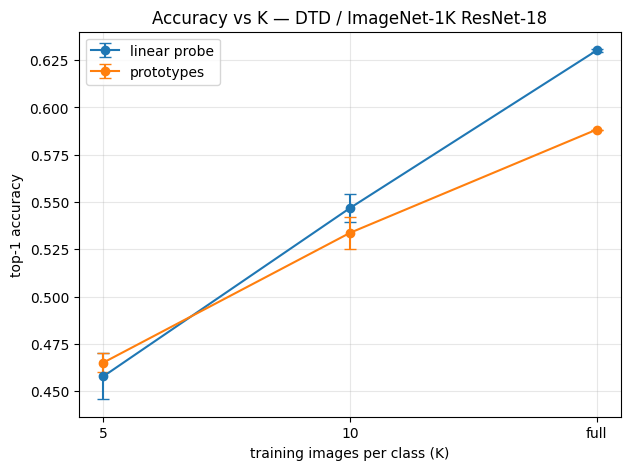

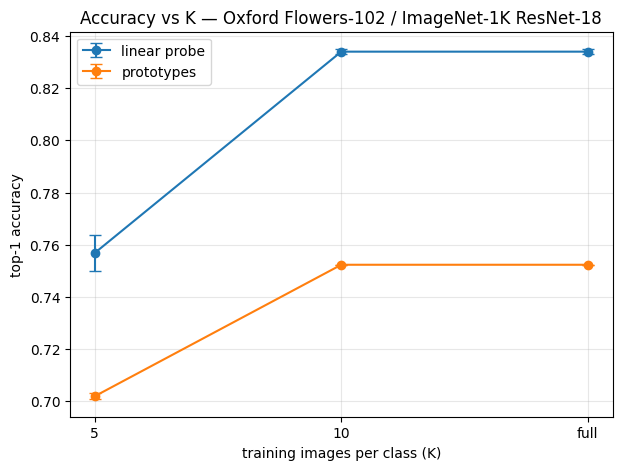

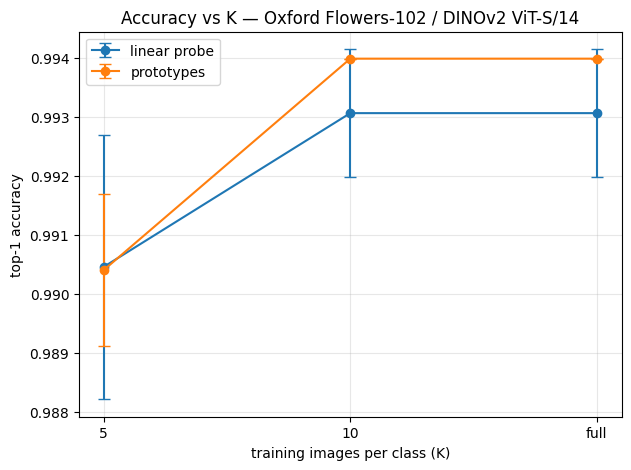

In [ ]:
xticks = ['5', '10', 'full']

for ds, cfg in DATASETS.items():
    for enc in cfg['encoders']:
        fig, ax = plt.subplots(figsize=(7, 5))
        for label, res in (('linear probe', linear_results), ('prototypes', proto_results)):
            ks = res[ds][enc]
            xs = [k for k in xticks if k in ks]
            ax.errorbar([xticks.index(k) for k in xs],
                        [ks[k]['mean'] for k in xs],
                        yerr=[ks[k]['std'] for k in xs],
                        marker='o', capsize=4, label=label)
        ax.set_xticks(range(len(xticks)))
        ax.set_xticklabels(xticks)
        ax.set_xlabel('training images per class (K)')
        ax.set_ylabel('top-1 accuracy')
        ax.set_title(f"Accuracy vs K — {cfg['name']} / {ENCODERS[enc]['name']}")
        ax.grid(alpha=0.3)
        ax.legend()
        plt.show()

### Observations

- **DTD** is the only genuinely informative curve, and it keeps rising through
  `full`: the linear probe crosses above the prototype method between 5 and 10
  shots and the gap widens with more data. Neither curve has saturated at 40 images
  per class,  **suggesting DTD accuracy is limited by the *features*, not by the
  amount of supervision.**

- **Flowers-102** curves flatten between 10 and `full` purely because those two
  settings are identical (see the caveat above); the only real information is the
  5 → 10 step.
- **DINOv2** is nearly flat at the top of the axis: accuracy is already ~99 % at 5
  shots, so there is almost no headroom, and the error bars are correspondingly tiny.
- Error bars shrink consistently as `K` grows, for both methods.

## 5.3 Training curves

Representative linear-probe training and validation curves — one 10-shot run
(seed 0) per dataset/encoder combination. These show whether optimisation is
stable and whether substantial overfitting occurs. The dashed line marks the
selected (best-validation-accuracy) checkpoint.

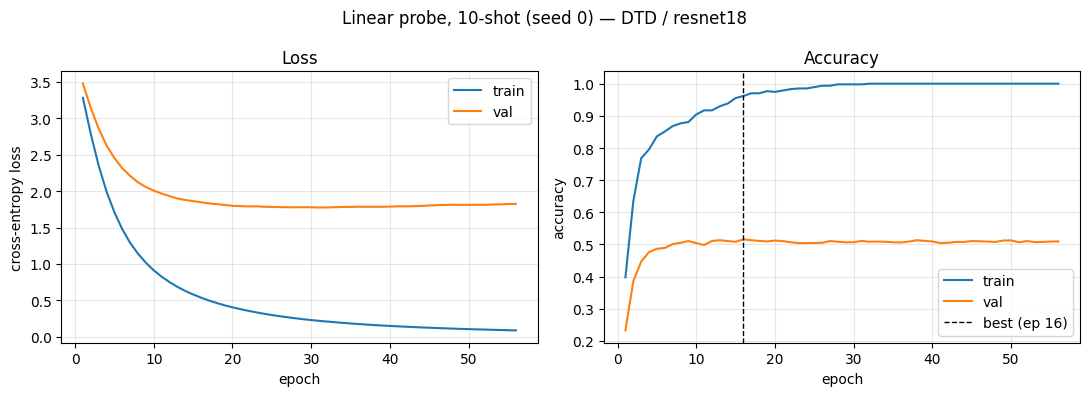

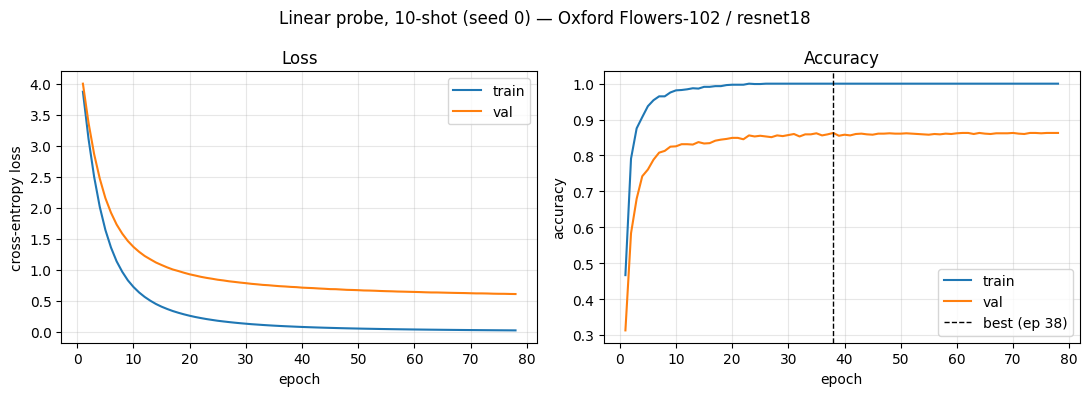

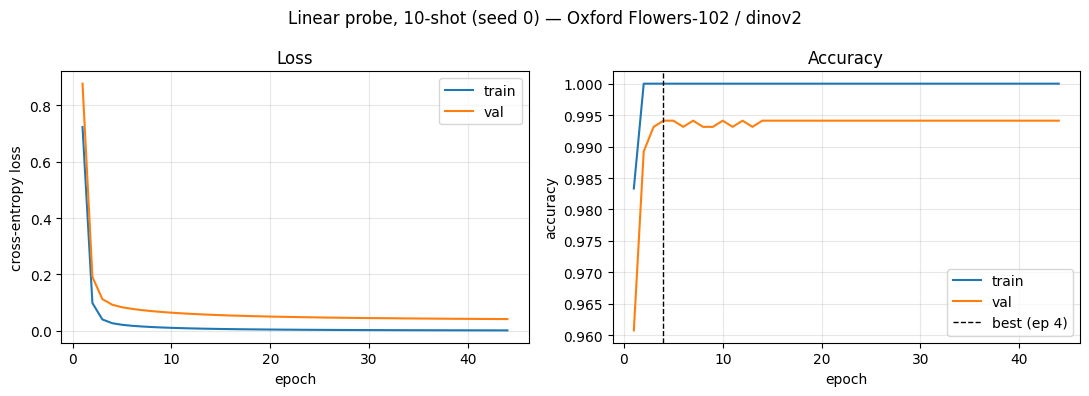

,run,epochs run,best epoch,train acc @best,val acc @best,train-val gap,min val loss,val loss @end,val loss rising
0,dtd/resnet18,56,16,0.9617,0.5160,0.4457,1.7749,1.8257,YES
1,flowers102/resnet18,78,38,1.0000,0.8627,0.1373,0.6106,0.6106,no
2,flowers102/dinov2,44,4,1.0000,0.9941,0.0059,0.0416,0.0416,no


In [ ]:
for (ds, enc), h in histories.items():
    epochs = range(1, len(h['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.plot(epochs, h['train_loss'], label='train')
    ax1.plot(epochs, h['val_loss'], label='val')
    ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, h['train_acc'], label='train')
    ax2.plot(epochs, h['val_acc'], label='val')
    ax2.axvline(h['best_epoch'] + 1, color='k', ls='--', lw=1,
                label=f"best (ep {h['best_epoch'] + 1})")
    ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

    fig.suptitle(f"Linear probe, 10-shot (seed 0) — {DATASETS[ds]['name']} / {enc}")
    fig.tight_layout()
    plt.show()

# Quantify stability / overfitting.
rows = []
for (ds, enc), h in histories.items():
    be = h['best_epoch']
    mn = min(h['val_loss'])
    # +1 so the table matches the 1-indexed epoch shown on the plots above.
    rows.append({'run': f'{ds}/{enc}', 'epochs run': len(h['train_loss']),
                 'best epoch': be + 1,
                 'train acc @best': round(h['train_acc'][be], 4),
                 'val acc @best': round(h['val_acc'][be], 4),
                 'train-val gap': round(h['train_acc'][be] - h['val_acc'][be], 4),
                 'min val loss': round(mn, 4),
                 'val loss @end': round(h['val_loss'][-1], 4),
                 'val loss rising': 'YES' if h['val_loss'][-1] > mn * 1.02 else 'no'})
display(pd.DataFrame(rows))

### Observations

Training is **stable in every case**: the training loss decreases smoothly with the
suggested hyper-parameters, so no tuning was required. The degree of overfitting,
however, differs sharply and tracks the quality of the features:

- **DTD / ResNet-18 — substantial overfitting.** The probe reaches **96.2 % training
  accuracy but only 51.6 % validation accuracy** (a ~44.6-point gap), and the
  validation loss bottoms out around epoch 30 and then *rises* while the training
  loss keeps falling towards 0.09. With only 470 training images (10 × 47) in a
  512-dimensional space this is expected, and it is exactly why selecting the
  checkpoint by best validation accuracy matters here.
- **Flowers-102 / ResNet-18 — mild overfitting.** Training accuracy saturates at
  100 % against 86.3 % validation (a ~13.7-point gap), but the validation loss is
  still decreasing when training stops, so the model is not yet degrading.
- **Flowers-102 / DINOv2 — essentially none.** Validation accuracy hits 99.4 %
  within ~3 epochs and the train-validation gap is only ~0.6 points. The problem is
  close to linearly separable in DINOv2 space, so there is nothing to overfit.

The number of epochs actually run (56 / 78 / 44) is well below the 200-epoch cap in
all three cases, confirming that early stopping triggered only *after* the selected
checkpoint and did not truncate useful training.

## 5.4 Confusion matrices

One **row-normalized** confusion matrix per dataset, for a representative setting:
the linear probe with the full training split on ResNet-18 (the encoder common to
both datasets). Rows are true classes, columns predicted classes, so the diagonal
is per-class recall.

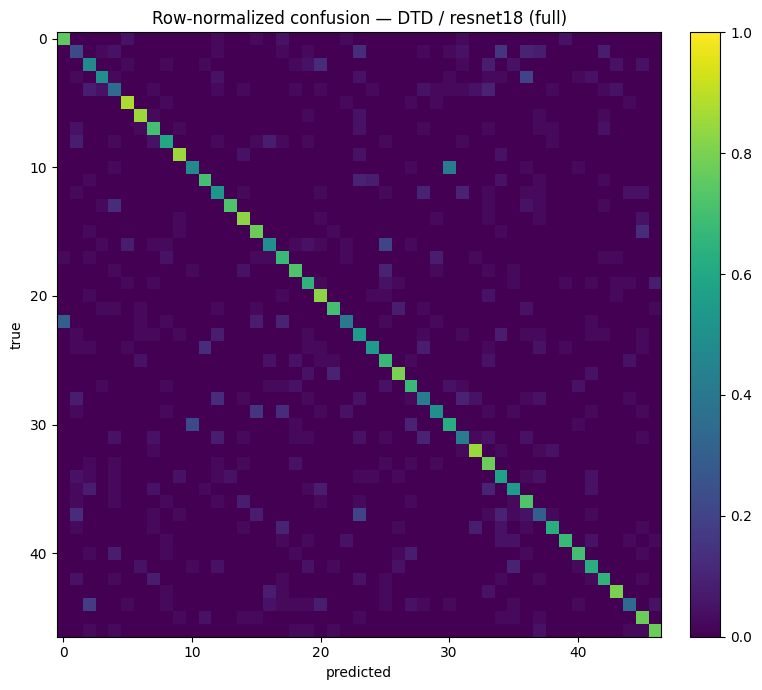

=== DTD / resnet18 — overall top-1 = 0.6309 ===
  mean-per-class accuracy : 0.6309  (test images/class: min 40, max 40)
  hardest classes : blotchy (0.23), stained (0.30), woven (0.35), bumpy (0.35), lined (0.40)
  easiest classes : chequered (0.88), crystalline (0.85), potholed (0.85), cobwebbed (0.85)
  top confusions (true -> predicted, rate):
              dotted -> polka-dotted   0.42
               lined -> banded         0.30
        polka-dotted -> dotted         0.23
              bubbly -> sprinkled      0.20
             stained -> marbled        0.20
                grid -> meshed         0.20



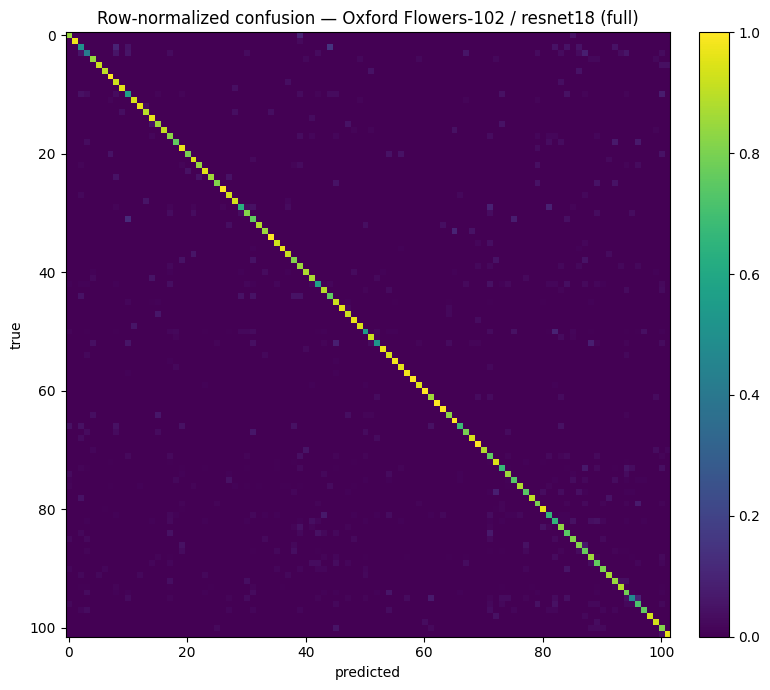

=== Oxford Flowers-102 / resnet18 — overall top-1 = 0.8328 ===
  mean-per-class accuracy : 0.8510  (test images/class: min 20, max 238)
  hardest classes : sweet pea (0.42), camellia (0.48), canterbury bells (0.50), primula (0.52), petunia (0.55)
  easiest classes : osteospermum (1.00), tree poppy (1.00), orange dahlia (1.00), cautleya spicata (1.00)
  top confusions (true -> predicted, rate):
      canterbury bells -> bolero deep blue 0.15
        garden phlox -> snapdragon     0.12
       pink primrose -> lenten rose    0.10
      canterbury bells -> monkshood      0.10
       mexican aster -> osteospermum   0.10
            camellia -> mallow         0.10



In [ ]:
for ds, cfg in DATASETS.items():
    enc = cfg['encoders'][0]                       # ResNet-18: common to both
    y_true, y_pred = predictions[(ds, enc)]
    names = load_class_names(ds) or [str(i) for i in range(cfg['num_classes'])]
    cm = confusion_matrix(y_true, y_pred, cfg['num_classes'], normalize=True)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='viridis', vmin=0.0, vmax=1.0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f"Row-normalized confusion — {cfg['name']} / {enc} (full)")
    fig.tight_layout()
    plt.show()

    # Which classes fail, and what are they mistaken for?
    per_class = np.diag(cm)
    off = cm.copy()
    np.fill_diagonal(off, 0.0)
    # The Flowers-102 test split is unbalanced (20-238 images per class), so we
    # also report mean-per-class accuracy, which weights every class equally.
    counts = np.bincount(y_true, minlength=cfg['num_classes'])
    print(f"=== {cfg['name']} / {enc} — overall top-1 = {top1_accuracy(y_true, y_pred):.4f} ===")
    print(f'  mean-per-class accuracy : {per_class.mean():.4f}'
          f'  (test images/class: min {counts.min()}, max {counts.max()})')
    print('  hardest classes :', ', '.join(f'{names[c]} ({per_class[c]:.2f})'
                                           for c in np.argsort(per_class)[:5]))
    print('  easiest classes :', ', '.join(f'{names[c]} ({per_class[c]:.2f})'
                                           for c in np.argsort(per_class)[-4:][::-1]))
    print('  top confusions (true -> predicted, rate):')
    for flat in np.argsort(off, axis=None)[::-1][:6]:
        i, j = np.unravel_index(flat, off.shape)
        print(f'      {names[i]:>14s} -> {names[j]:<14s} {off[i, j]:.2f}')
    print()

### Observations

The most useful finding is that **the errors are not random — they occur between
semantically near-synonymous categories.** On DTD the dominant confusions are
`dotted → polka-dotted` (0.42), `polka-dotted → dotted` (0.23), `lined → banded`
(0.30), `grid → meshed` (0.20), `bubbly → sprinkled` (0.20) and `stained → marbled`
(0.20). These are pairs a human annotator could plausibly disagree on, so a
meaningful share of the remaining DTD error reflects genuine label ambiguity rather
than a failure of the representation.

The per-class spread is wide. Textures defined by clear repeating geometric
structure are easy — `chequered` (0.88), `crystalline`, `potholed` and `cobwebbed`
(0.85 each) — while diffuse, low-structure textures are hardest: `blotchy` (0.23),
`stained` (0.30), `woven` and `bumpy` (0.35). ImageNet features encode shape and
repeated pattern well, but carry much less information about unstructured surface
appearance.

**The same pattern holds on Flowers-102** once the numeric labels are mapped to real
names. The matrix is strongly diagonal (83.28 % on the seed-0 run shown here) and the
leading confusions are `canterbury bells → bolero deep blue` (0.15),
`garden phlox → snapdragon` (0.12), `pink primrose → lenten rose` (0.10),
`canterbury bells → monkshood` (0.10), `mexican aster → osteospermum` (0.10) and
`camellia → mallow` (0.10) — in every case a pair of flowers of similar colour and
shape. Errors are spread thinly rather than concentrated: the largest single
off-diagonal entry is only 0.15. The hardest classes are `sweet pea` (0.42),
`camellia` (0.48), `canterbury bells` (0.50) and `primula` (0.52), while
`osteospermum`, `tree poppy`, `orange dahlia` and `cautleya spicata` are classified
perfectly.

**Balanced vs. plain accuracy.** The Flowers-102 test split is strongly unbalanced
(20 to 238 images per class), so overall top-1 is dominated by the largest classes.
Weighting every class equally gives a **mean-per-class accuracy of 85.10 %**, about
1.8 points *above* the 83.28 % top-1 figure — the larger classes are slightly harder
than the small ones. We report plain top-1 throughout because the brief specifies it,
and since the two measures agree closely no conclusion changes. DTD's test split is
perfectly balanced (40 images per class), so for it the two numbers are identical by
construction (63.09 %).

> *Note on class names:* torchvision provides no names for Flowers-102, so we map its
> label ids onto the standard published ordering of the 102 categories. That every top
> confusion turns out to be a visually plausible flower pair is a good independent
> check that the mapping is correct.

## 5.5 Feature visualizations

Two-dimensional t-SNE projections of the **test** features for a readable subset of
10 classes, with the image-derived class prototypes overlaid as stars.

Following the brief, the same class subset and colour assignment is used across
encoders on a given dataset, and the projection is fit **jointly** on the image
features and the prototypes shown. Features and prototypes are L2-normalized before
projecting, because the prototype classifier operates in cosine space — without
this, unit-norm prototypes and raw features occupy different scales and the
prototypes collapse towards the origin instead of landing on their classes.

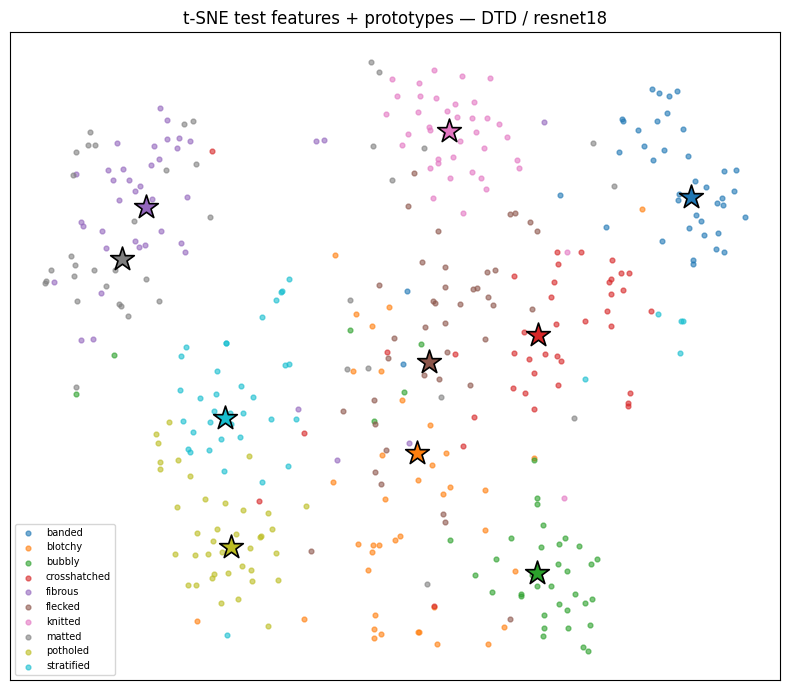

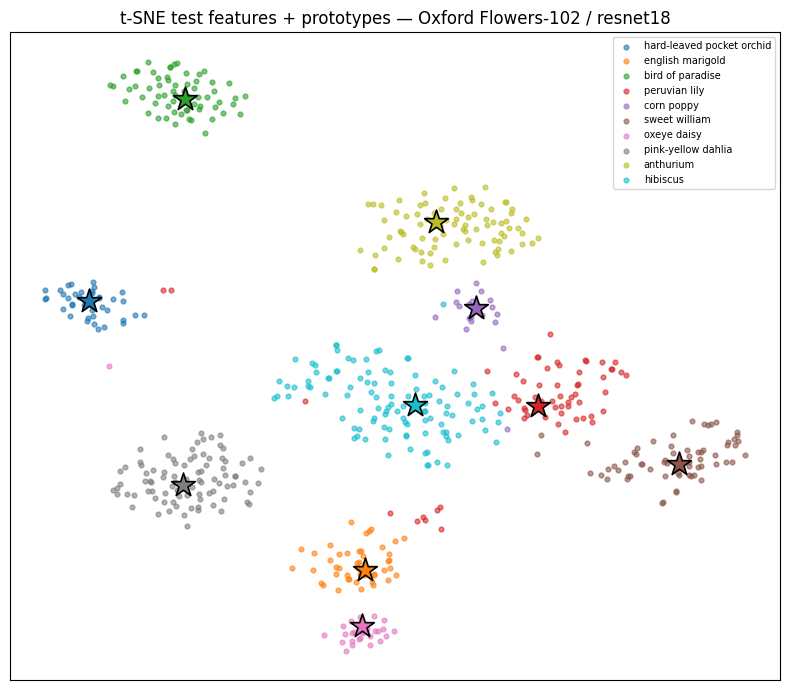

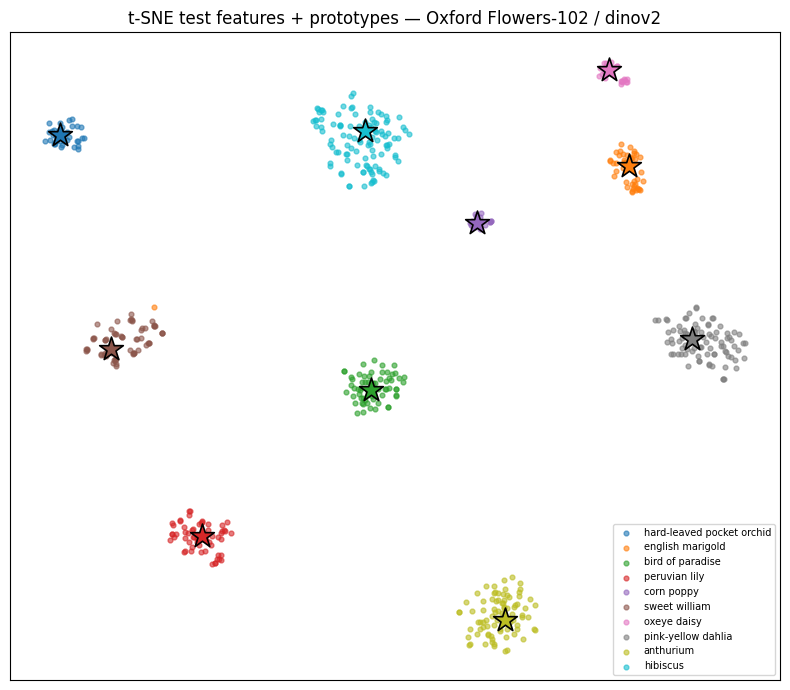

In [ ]:
from sklearn.manifold import TSNE

N_SHOW = 10

for ds, cfg in DATASETS.items():
    # Same class subset across encoders for a like-for-like comparison.
    rng = np.random.default_rng(0)
    class_ids = sorted(rng.choice(cfg['num_classes'], size=N_SHOW, replace=False).tolist())
    names = load_class_names(ds)

    for enc in cfg['encoders']:
        Xte, yte = load_features(ds, enc, 'test')
        Xtr, ytr = load_features(ds, enc, 'train')
        protos = compute_prototypes(Xtr, ytr, cfg['num_classes'])

        mask = np.isin(yte, class_ids)
        Xs, ys = l2_normalize(Xte[mask], axis=1), yte[mask]
        ps = l2_normalize(protos[class_ids], axis=1)

        # Fit the projection jointly on image features and prototypes.
        proj = TSNE(n_components=2, random_state=0, init='pca',
                    perplexity=min(30, max(5, (len(Xs) - 1) // 3))
                    ).fit_transform(np.vstack([Xs, ps]))
        pts, pp = proj[:len(Xs)], proj[len(Xs):]

        fig, ax = plt.subplots(figsize=(8, 7))
        cmap = plt.get_cmap('tab10')
        for i, c in enumerate(class_ids):
            m = ys == c
            color = cmap(i % 10)
            ax.scatter(pts[m, 0], pts[m, 1], s=12, color=color, alpha=0.6,
                       label=names[c] if names else f'class {c}')
            ax.scatter(pp[i, 0], pp[i, 1], marker='*', s=320, color=color,
                       edgecolors='black', linewidths=1.2)
        ax.set_title(f"t-SNE test features + prototypes — {cfg['name']} / {enc}")
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(fontsize=7, loc='best')
        fig.tight_layout()
        plt.show()

### Observations

The projections line up closely with the quantitative results:

- **Flowers-102 / DINOv2** produces extremely tight, well-separated, roughly
  spherical clusters with almost no inter-class mixing. Some clusters are so compact
  that they are hidden behind their own prototype marker. This is the visual
  counterpart of ~99 % accuracy and of the fact that a nearest-centroid rule performs
  as well as a trained linear classifier.

  -----------The classes form very tight, well-separated clusters, which explains the near-99% accuracy.

- **Flowers-102 / ResNet-18** still shows clearly identifiable clusters, but they are
  visibly broader, closer together, and have a few stray points crossing between
  classes — consistent with 83 % accuracy.

  --------------The clusters are still clear but more spread out and overlapping, which matches the lower 83% accuracy.
- **DTD / ResNet-18** is the most entangled. Well-structured textures such as
  `knitted`, `banded`, `potholed` and `stratified` form recognisable groups, whereas
  `blotchy`, `flecked`, `matted` and `crosshatched` are dispersed through a crowded
  central region with no clean boundaries. Their prototypes consequently sit inside
  that mixed region, which is precisely why those classes have the lowest per-class
  recall.

  ---------------The features are heavily mixed, so several texture classes are hard to separate and have lower recall.

In every plot each prototype lies at the centre of its class's point cloud, which is
the expected behaviour for a (normalized) class mean and confirms the prototype
implementation.

> These 2-D projections are **qualitative**. t-SNE does not preserve global distances
> and its layout depends on perplexity and initialization, so apparent cluster
> separation should not be read as a direct measure of accuracy.

---
# Part 6 — Conclusions

1. **The frozen representation dominates everything else.** Swapping ResNet-18 for
   DINOv2 on Flowers-102 is worth ~16 accuracy points — far more than any choice of
   classifier or amount of labeled data we varied. DINOv2 at 5 shots (99.05 %)
   comfortably beats ResNet-18 with the full training split (83.40 %).
2. **Prototypes are a remarkably strong low-shot baseline.** At 5 shots they match or
   beat the trained linear probe (DTD: 46.51 % vs. 45.78 %) despite involving no
   training at all. Their weakness is that they stop improving: given more data the
   linear probe wins decisively (DTD-full: 63.01 % vs. 58.83 %).
3. **Overfitting is concentrated exactly where the features are weak.** The DTD
   10-shot probe reaches 96 % train vs. 52 % validation accuracy with a rising
   validation loss, whereas the DINOv2 probe shows a ~0.6-point gap. Selecting the
   checkpoint by validation accuracy is therefore essential on DTD and almost
   irrelevant on Flowers/DINOv2.
4. **Residual error is largely semantic, on both datasets.** The largest DTD
   confusions are between near-synonymous textures (`dotted`/`polka-dotted`,
   `lined`/`banded`, `grid`/`meshed`), and on Flowers-102 between visually similar
   species (`canterbury bells`/`monkshood`, `pink primrose`/`lenten rose`,
   `camellia`/`mallow`). In both cases the raw top-1 figure understates the practical
   quality of the predictions.
5. **Domain match matters.** An object-centric ImageNet encoder transfers much better
   to Flowers-102 (natural objects) than to DTD (textures), which is visible in the
   accuracy, the overfitting behaviour and the t-SNE structure alike.

### Limitations

- On Flowers-102, `10-shot` and `full` coincide, so that dataset contributes only one
  meaningful point to the accuracy-versus-size analysis.
- DINOv2 was run on a single dataset (as the brief allows), so we cannot tell whether
  its advantage is equally large on textures.
- DINOv2 accuracy on Flowers-102 is close to ceiling, which compresses any differences
  between the two baselines there.
- We deliberately did not perform an extensive hyper-parameter search; the suggested
  configuration trained stably in all runs, so it was kept unchanged.
- The Flowers-102 test split is unbalanced (20–238 images per class). We report the
  prescribed top-1 accuracy, and also mean-per-class accuracy as a cross-check; the
  two differ by under 2 points, so the ranking of methods is unaffected.

### Carrying forward

The **image-derived prototype** branch is the one that carries into **Stage 2**, and
the **linear-probe** setting is the one used in **Stage 3**. Both rest on the same
cached frozen features produced here, so the comparison against the flow-matching
layer will be like-for-like.

### Reproducibility

Every result is deterministic: subset selection, classifier initialization, batch
shuffling and t-SNE are all driven by fixed seeds, so re-running this notebook
reproduces the numbers quoted in the discussion exactly.